Import af biblioteker og dataindhentning. Der tilføjes også en konstant kolonne

In [21]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
data = pd.read_stata(r"A1_kommune.dta")
taxrate = data["taxrate"]
taxrev = data["taxrev"]
data['const'] = 1


Problem 1 - Deskriptiv

In [20]:
print(data.describe())

               nr        taxrev    taxrate            pop  const
count   98.000000     98.000000  98.000000      98.000000   98.0
mean   462.173469   4477.341309  25.208162   56475.887755    1.0
std    236.555437   5251.175293   0.908003   62925.301713    0.0
min    101.000000    211.228409  22.799999    1969.000000    1.0
25%    242.500000   2466.702271  24.799999   29997.750000    1.0
50%    435.000000   3317.848633  25.299999   43475.000000    1.0
75%    697.250000   4786.060913  25.700001   59733.000000    1.0
max    860.000000  44170.335938  27.799999  528208.000000    1.0


Problem 2
Første model

In [ ]:
def OLS_SLR(x,y):
    x_bar = np.mean(x)
    y_bar = np.mean(y)

    cov_xy = np.sum((x-x_bar)*(y-y_bar))
    var_x  = np.sum((x-x_bar)**2)

    beta1hat = cov_xy / var_x 
    beta0hat = y_bar-beta1hat*x_bar

    y_hat = beta0hat+beta1hat*x

    u_hat = y - y_hat

    SST = np.sum((y-y_bar)**2)
    SSE = np.sum((y_hat - y_bar)**2)
    SSR = np.sum(u_hat**2)

    R2 = SSE / SST
    sigma2 = 1 / (len(x)-2) * SSR
    varBeta1 = sigma2 / var_x
    varBeta0 = (sigma2 * np.sum(x**2))/var_x
    seBeta1 = np.sqrt(varBeta1)
    seBeta0 = np.sqrt(varBeta0)
    
    returnDict = {"beta0hat": beta0hat, "beta1hat": beta1hat, "yhat": y_hat, "uhat": u_hat, "SST": SST, "SSE": SSE, "SSR" : SSR, "R2":R2, "sigma2": sigma2, "varBeta0": varBeta0, "varBeta1": varBeta1, "seBeta0": seBeta0, "seBeta1": seBeta1}

    return beta0hat, beta1hat, R2, seBeta0, seBeta1, SST, SSE, SSR

tilOls = data
tilOls = tilOls.drop(columns = ["nr","kommune","pop","taxrev","const"])
beta0hat, beta1hat, R2, seBeta0, seBeta1, SST, SSE, SSR = OLS_SLR(tilOls["taxrate"],np.log(taxrev))
print(beta0hat)
#skriv printeprinte

11.698206


Sanity check med Statsmodels

In [19]:

model1 = sm.OLS(np.log(taxrev), data[['const', 'taxrate']]).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 taxrev   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     2.818
Date:                Tue, 15 Sep 2026   Prob (F-statistic):             0.0965
Time:                        10:44:03   Log-Likelihood:                -111.12
No. Observations:                  98   AIC:                             226.2
Df Residuals:                      96   BIC:                             231.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.6982      2.143      5.459      0.0

Problem 2 anden model

In [89]:
def OLS(X, y):

    X = X.to_numpy()
    y = y.to_numpy()

    n = X.shape[0]
    k = X.shape[1] - 1

    betahat = np.linalg.inv(X.T @ X) @ X.T @ y
    
    yhat = X @ betahat
    uhat = y - yhat
    
    ybar = y.mean()

    SST = np.sum((y - ybar)**2)
    SSE = np.sum((yhat - ybar)**2)
    SSR = np.sum(uhat**2)

    R2 = SSE / SST
    
    sigma2 = np.dot(uhat, uhat) * 1/(n-k-1)

    var_betahat = sigma2 * np.linalg.inv(X.T @ X)
    se_betahat = np.sqrt(np.diag(var_betahat))

    prikprodU = uhat.T @ uhat
    covMatrix = sigma2 * np.linalg.inv(X.T @ X)

    return {
        'betahat': betahat,
        'se_betahat': se_betahat,
        'yhat': yhat,
        'uhat': uhat,
        'sigma2': sigma2,
        'R2': R2,
        'SST': SST,
        'SSE': SSE,
        'SSR': SSR,
        'Cov': covMatrix
    }
tilOls = data
y = np.log(tilOls['taxrev'])
tilOls['const'] = 1
tilOls['log_pop'] = np.log(tilOls['pop'])
X = tilOls[['const', 'taxrate', 'log_pop']]
OLS(X,y)


{'betahat': array([-2.80216572,  0.02262227,  0.97110107]),
 'se_betahat': array([0.37557591, 0.01245395, 0.01439294]),
 'yhat': array([10.53268146,  8.86821672,  8.23509207,  7.87878807,  6.99906275,
         8.56195456,  8.48913962,  7.42355315,  7.62659942,  7.68896846,
         8.27868739,  8.21723879,  8.28358361,  7.97357924,  7.40966583,
         8.02006616,  7.03968965,  8.03251651,  7.56811227,  8.04386832,
         8.47491638,  8.2336996 ,  7.53897333,  8.30567148,  8.10568426,
         8.1707188 ,  7.81772627,  8.05918738,  8.12508882,  8.20243592,
         8.39759607,  8.754786  ,  7.41353767,  7.90405992,  8.59323719,
         7.95745974,  8.26289487,  7.89312017,  8.68897921,  7.47018375,
         7.79049974,  7.67372168,  8.24852932,  8.74031573,  8.51166258,
         8.19396627,  8.01337912,  8.12730685,  8.33504721,  7.57326434,
         7.85253057,  9.54932814,  8.47190775,  7.78525909,  7.06305578,
         6.34049426,  8.42045792,  7.64594282,  8.68721712,  8.046728

Problem 2 - sanity check med statsmodels



In [16]:
data["log_pop"] = np.log(data["pop"])
model2 = sm.OLS(np.log(taxrev),data[["const", "taxrate","log_pop"]]).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 taxrev   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     2344.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           1.42e-81
Time:                        10:42:39   Log-Likelihood:                 79.497
No. Observations:                  98   AIC:                            -153.0
Df Residuals:                      95   BIC:                            -145.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8022      0.376     -7.461      0.0

Problem 3 


In [15]:
model3 = sm.OLS(np.log(taxrev),data[["const","log_pop"]]).fit()
print(model3.summary())
data["res1"] = model3.resid

                            OLS Regression Results                            
Dep. Variable:                 taxrev   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     4576.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           8.47e-83
Time:                        10:25:16   Log-Likelihood:                 77.824
No. Observations:                  98   AIC:                            -151.6
Df Residuals:                      96   BIC:                            -146.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1772      0.152    -14.287      0.0

In [ ]:
model4 = sm.OLS(np.log(taxrev),data[["res1"]]).fit()
print(model4.summary())

                                 OLS Regression Results                                
Dep. Variable:                 taxrev   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):             -0.010
Method:                 Least Squares   F-statistic:                            0.01751
Date:                Sun, 13 Sep 2026   Prob (F-statistic):                       0.895
Time:                        17:36:00   Log-Likelihood:                         -344.52
No. Observations:                  98   AIC:                                      691.0
Df Residuals:                      97   BIC:                                      693.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

<Axes: xlabel='res1', ylabel='taxrev'>

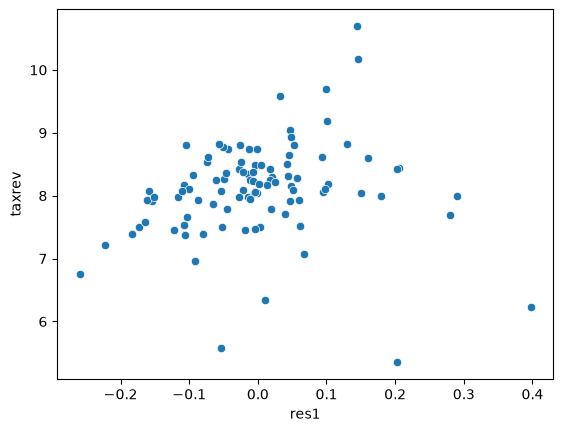

In [ ]:
#Test af scatterplot af residualerne og logrev
import seaborn as sns
sns.scatterplot(x = data["res1"], y = np.log(taxrev))